In [498]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [499]:
df = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df.shape)


Shape inicial: (1678326, 48)


In [500]:
# TARGET (MORTE)
# =============================

df["target_grave"] = (
    (df["mortos"] > 0) | (df["feridos_graves"] > 0)
).astype(int)

print(df["target_grave"].value_counts(normalize=True))

target_grave
0    0.825025
1    0.174975
Name: proportion, dtype: float64


In [501]:
# KM
df["km"] = (
    df["km"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["km"] = pd.to_numeric(df["km"], errors="coerce")

# Latitude / Longitude
df["latitude"] = (
    df["latitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["longitude"] = (
    df["longitude"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Idade veículo
df["idade_veiculo"] = 2025 - df["ano_fabricacao_veiculo"]

In [502]:
coords = df[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=100, random_state=42).fit(coords)
df['cluster_localizacao'] = kmeans.predict(df[['latitude', 'longitude']])

In [503]:
df['veiculo_velho'] = (df['idade_veiculo'] > 15).astype(int)
# No LightGBM, isso pode virar uma nova categoria ou feature combinada

In [504]:
df["km_bin"] = (df["km"] // 5) * 5

In [505]:
features = [
    "uf",
    "br",
    "km_bin",
    "hora",
    #'horario',
    "mes",
    "dia_semana",
    'dia_mes',
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    'veiculo_velho',
    "tipo_pista",
    #"tracado_via",
    "uso_solo", #*
    "tipo_veiculo",
    "idade",
    #'sexo',
    "idade_veiculo",
    'cluster_localizacao',
    'regional', 
    #'marca',
    #'Fabricante',
    #'Modelo'
]

# features = [
#     "hora",
#     "mes",
#     "dia_semana",
#     "tipo_acidente",
#     "fase_dia",
#     "condicao_metereologica",
#     "tipo_pista",
#     "tracado_via",
#     "uso_solo",
#     "tipo_veiculo",
#     "idade",
#     "idade_veiculo",
#     "Fabricante",
#     "Modelo"
# ]


df = df.dropna(subset=["target_grave"])

for col in features:
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
        
    else:
        df[col] = df[col].fillna("Desconhecido")

categoricas = df[features].select_dtypes(include="object").columns

for col in categoricas:
    df[col] = df[col].astype("category")

C:\Users\fause\AppData\Local\Temp\ipykernel_22244\1327660475.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df[features].select_dtypes(include="object").columns


In [506]:
X = df[features]
y = df["target_grave"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 importante (balanceamento)
)

In [507]:
import lightgbm as lgb

# modelo = lgb.LGBMRegressor(
#     n_estimators=400,
#     learning_rate=0.05,
#     num_leaves=64,
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512

# )

# modelo = lgb.LGBMRegressor(
#     n_estimators=800,          # mais árvores
#     learning_rate=0.03,        # aprendizado mais suave
#     num_leaves=128,            # mais capacidade
#     max_depth=-1,              # sem limite explícito
#     min_child_samples=40,      # evita overfitting
#     subsample=0.8,             # bagging
#     colsample_bytree=0.8,      # feature sampling
#     reg_alpha=0.5,             # regularização L1
#     reg_lambda=0.5,            # regularização L2
#     random_state=42,
#     n_jobs=-1,
#     force_col_wise=True,
#     max_bin=512
# )

# modelo.fit(X_train, y_train)

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale_pos_weight)
modelo = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    #scale_pos_weight=scale_pos_weight,
    scale_pos_weight=2.5,
    reg_alpha=0.3,
    reg_lambda=0.3,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

4.715100539730646
[LightGBM] [Info] Number of positive: 234932, number of negative: 1107728
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 821
[LightGBM] [Info] Number of data points in the train set: 1342660, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174975 -> initscore=-1.550770
[LightGBM] [Info] Start training from score -1.550770


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.05
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [508]:
pred = modelo.predict(X_test)
proba = modelo.predict_proba(X_test)[:,1]

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("ROC AUC:", roc_auc_score(y_test, proba))


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.88      0.90    276933
           1       0.51      0.59      0.55     58733

    accuracy                           0.83    335666
   macro avg       0.71      0.74      0.72    335666
weighted avg       0.84      0.83      0.83    335666

ROC AUC: 0.851619615699386


In [509]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definir a estratégia de validação (5 ou 10 folds é o padrão)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir as métricas que queremos monitorar
# 'f1_weighted' é bom para classes desbalanceadas, 
# 'roc_auc' mede a capacidade de separação
metricas = ['precision', 'recall', 'f1', 'roc_auc']

print(f"Iniciando Cross-Validation com {skf.get_n_splits()} folds...\n")

# 3. Executar o Cross-Validation
# Nota: Passamos o X e y completos (ou X_train e y_train)
cv_results = cross_validate(
    modelo, X, y, 
    cv=skf, 
    scoring=metricas, 
    n_jobs=-1, 
    return_train_score=False
)

# 4. Exibir os resultados médios
print("-" * 30)
print("RESULTADOS MÉDIOS (CV):")
print(f"ROC AUC:   {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f}")
print("-" * 30)

Iniciando Cross-Validation com 5 folds...

------------------------------
RESULTADOS MÉDIOS (CV):
ROC AUC:   0.8515 (+/- 0.0006)
Recall:    0.5870
Precision: 0.5113
F1-Score:  0.5465
------------------------------


In [510]:
import pandas as pd

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

                   feature  importance
2                   km_bin        4348
14                   idade        3922
15           idade_veiculo        3224
6                  dia_mes        2816
0                       uf        2767
17                regional        2693
3                     hora        2532
13            tipo_veiculo        2491
16     cluster_localizacao        2124
1                       br        2075
5               dia_semana        2030
4                      mes        1911
7            tipo_acidente        1765
9   condicao_metereologica        1293
11              tipo_pista         692


c:\Fause\Programas\EngSoft\repos\ML-Transportes\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


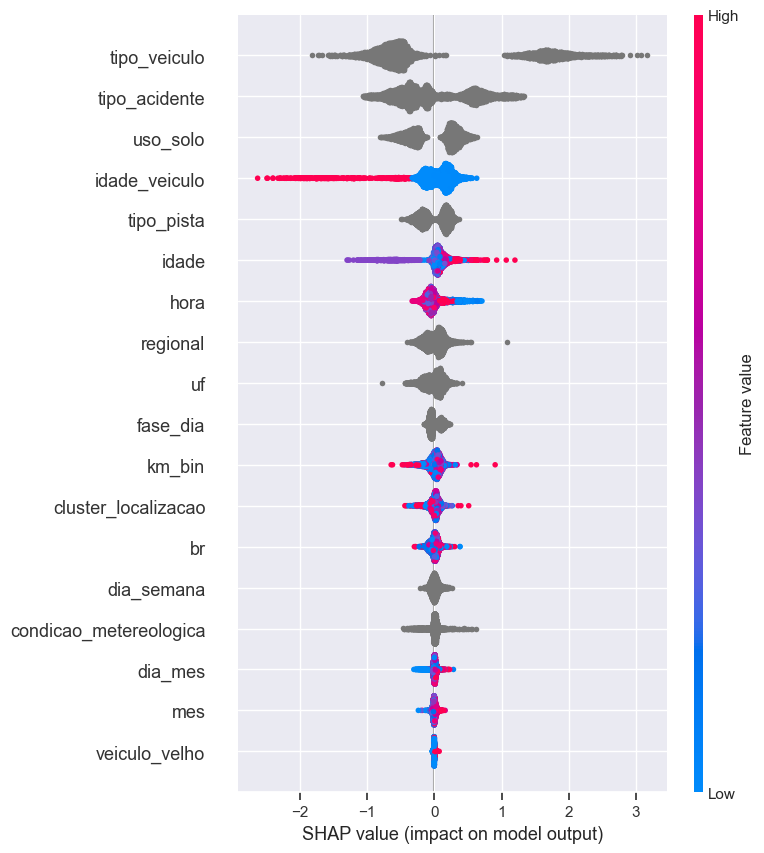

In [511]:
import shap

X_sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

In [512]:
print("Shape inicial:", df.shape)

Shape inicial: (1678326, 53)


                   feature  importance
2                   km_bin        4348
14                   idade        3922
15           idade_veiculo        3224
6                  dia_mes        2816
0                       uf        2767
17                regional        2693
3                     hora        2532
13            tipo_veiculo        2491
16     cluster_localizacao        2124
1                       br        2075
5               dia_semana        2030
4                      mes        1911
7            tipo_acidente        1765
9   condicao_metereologica        1293
11              tipo_pista         692


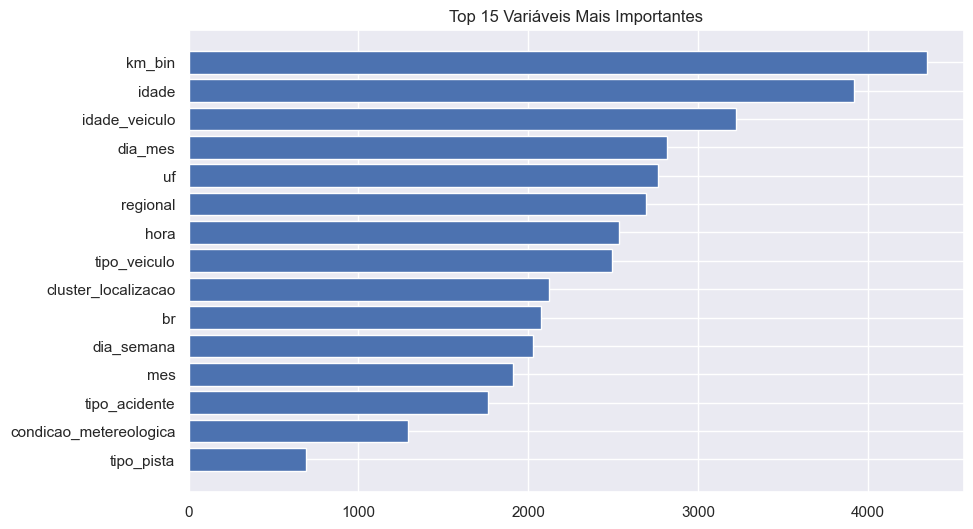

In [513]:
import pandas as pd
import matplotlib.pyplot as plt

importancia = pd.DataFrame({
    "feature": X.columns,
    "importance": modelo.feature_importances_
}).sort_values("importance", ascending=False)

print(importancia.head(15))

plt.figure(figsize=(10,6))
plt.barh(importancia["feature"][:15][::-1], importancia["importance"][:15][::-1])
plt.title("Top 15 Variáveis Mais Importantes")
plt.show()